Analysation of the data coming from the simulator.

In [1]:
import yaml
import math
import numpy as np
import xarray as xr
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import cm

In [2]:
environment = "office_space_inline"

# Read out the config file.
config_file = f"environments/{environment}/config.yaml"
with open(config_file, "r", encoding="utf8") as file:
    config = yaml.safe_load(file)

stripe_config = config["stripe_config"]

/tmp/ipykernel_38658/1554348342.py:23: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, ax = plt.subplots(subplot_kw={"projection": "3d"})


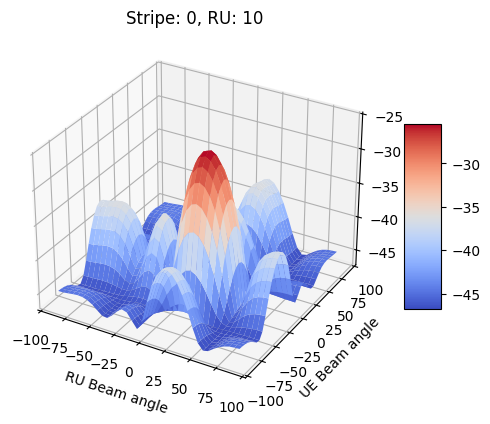

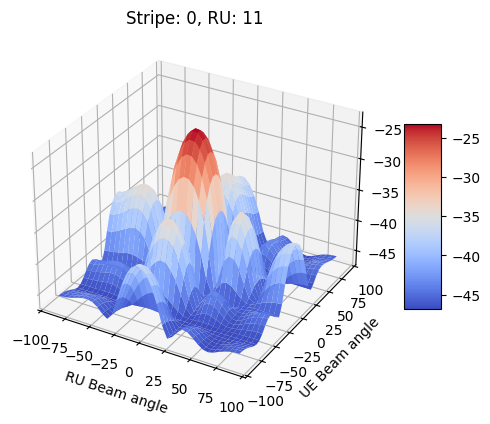

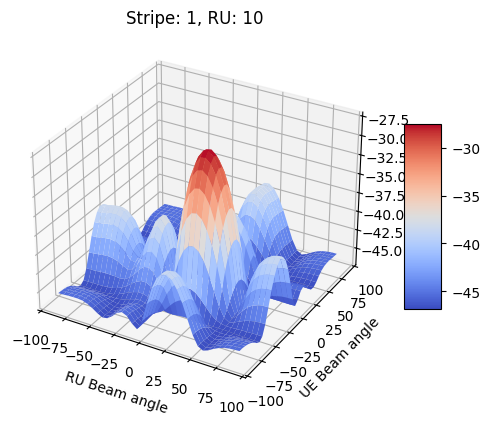

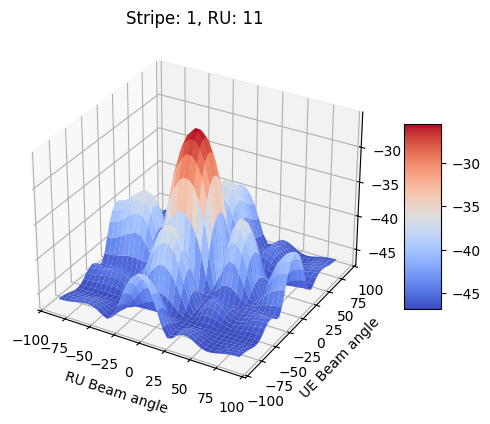

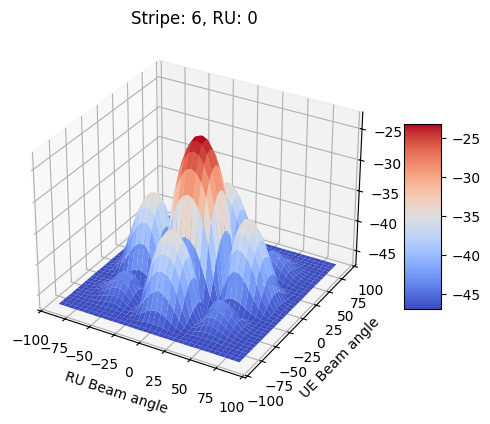

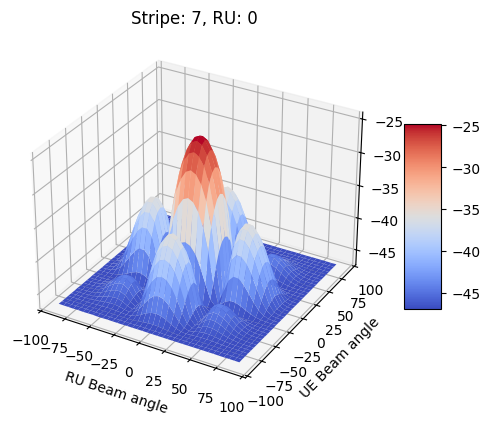

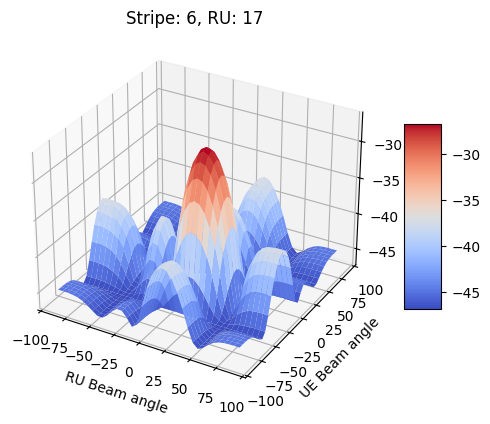

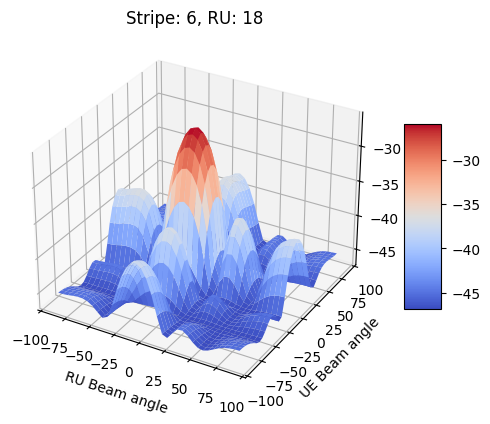

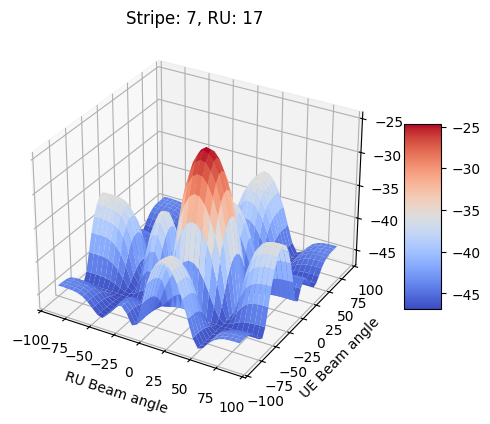

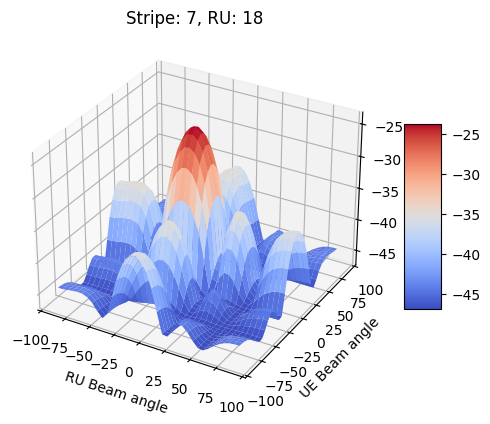

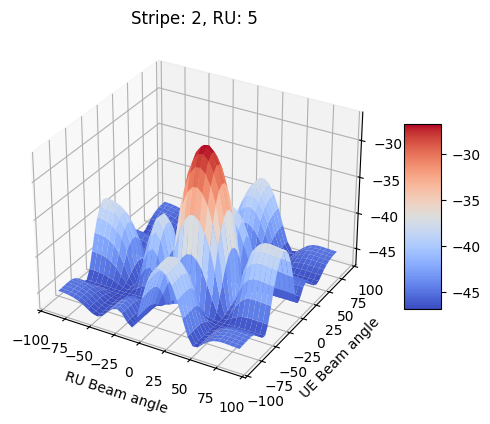

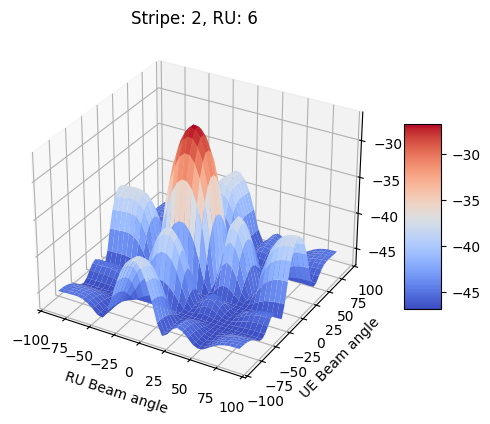

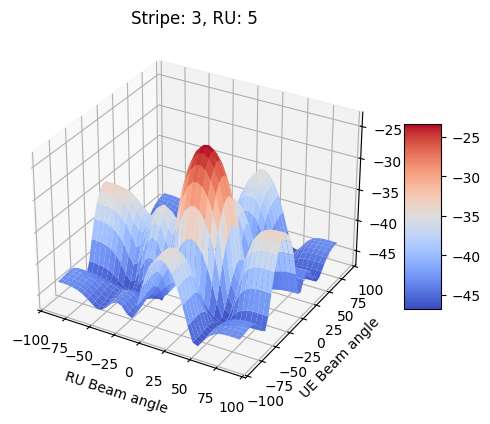

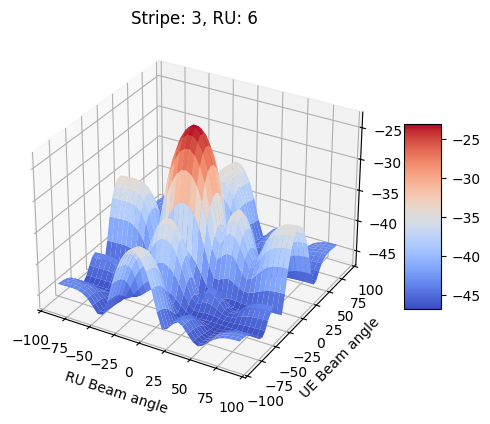

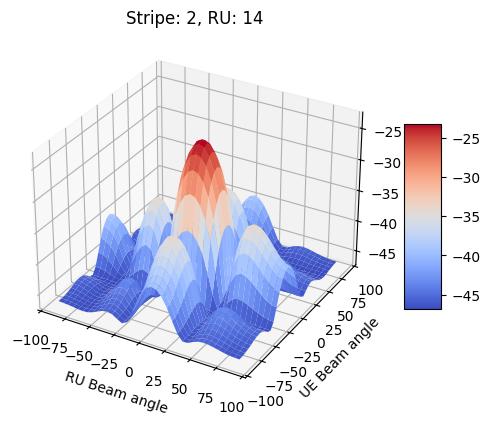

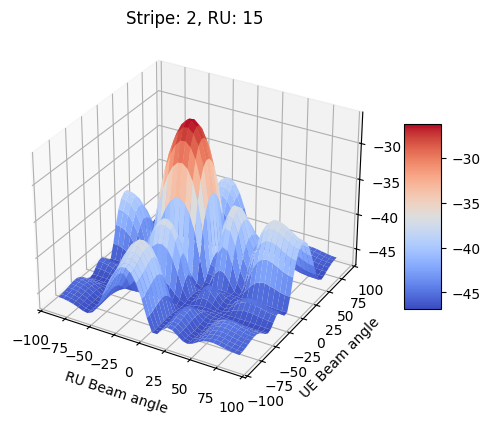

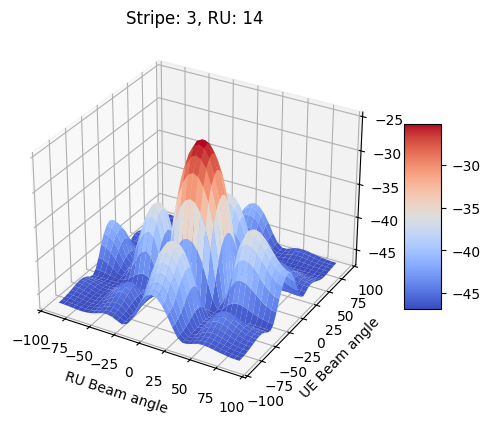

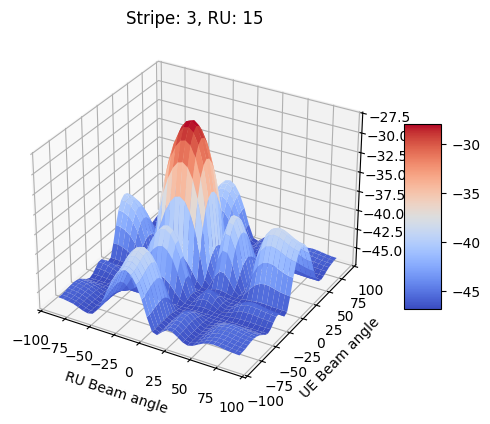

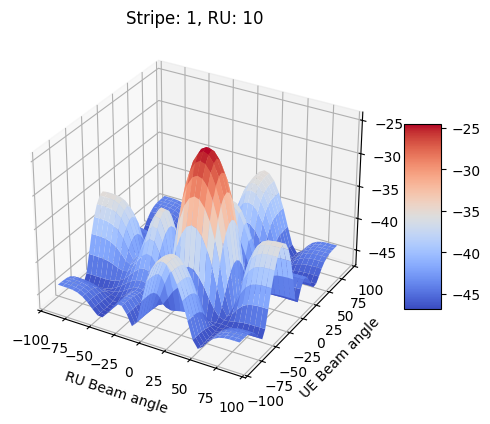

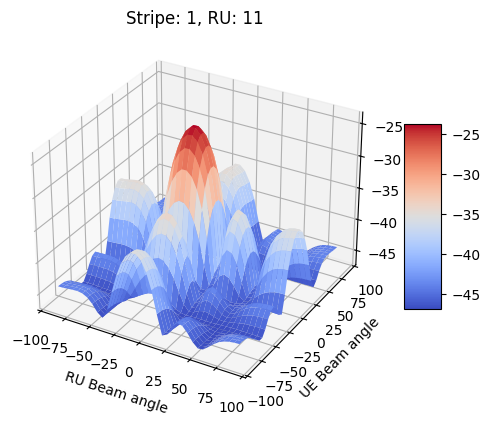

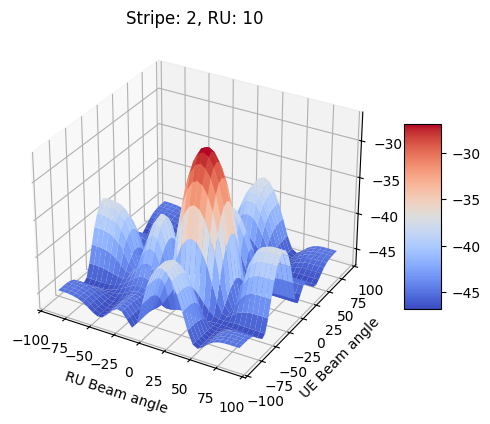

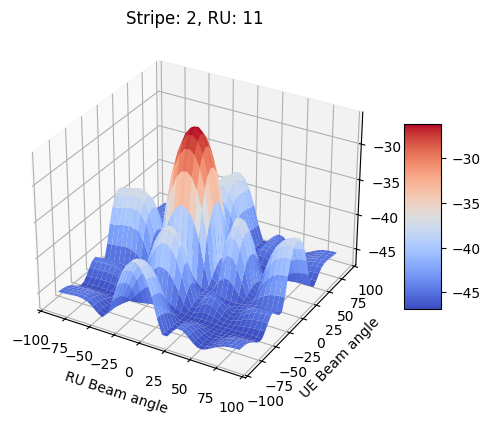

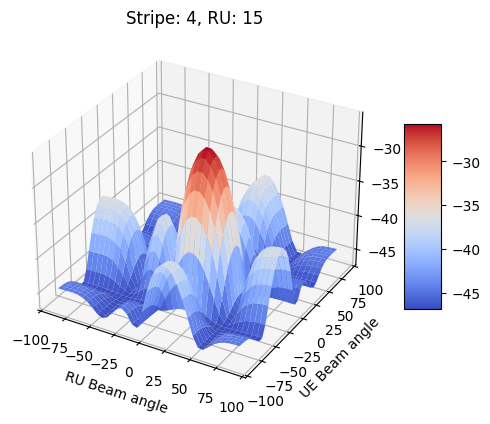

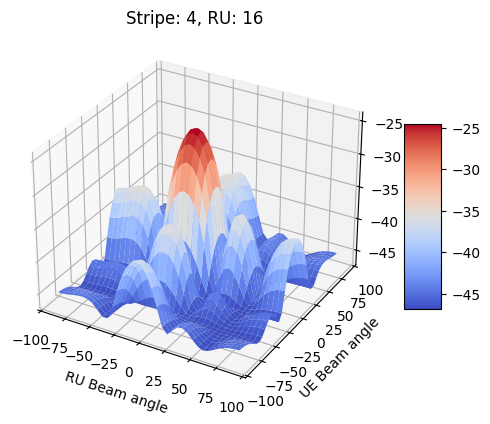

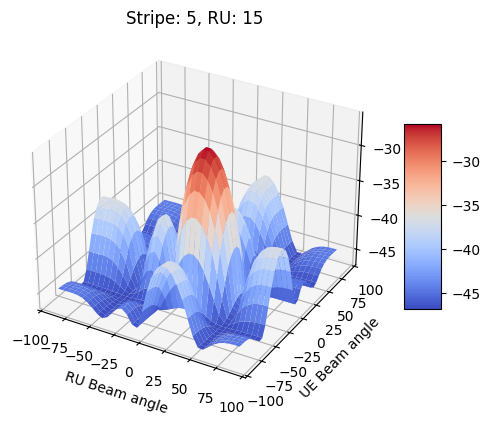

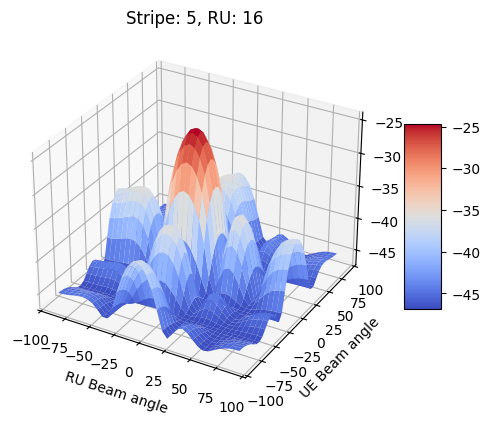

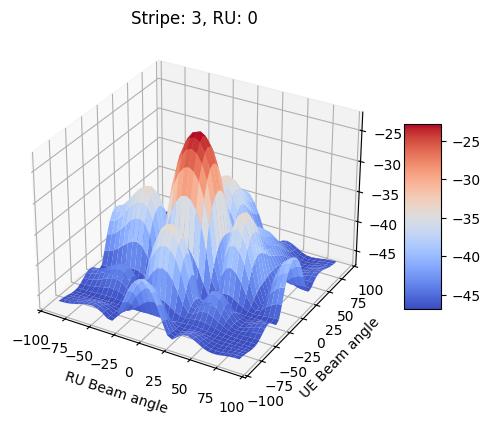

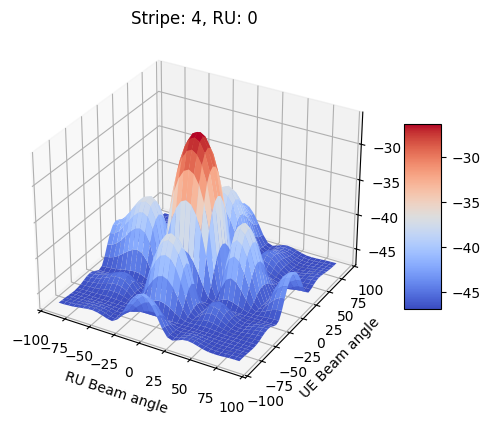

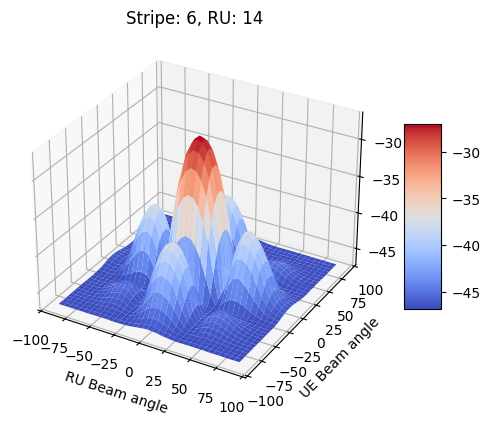

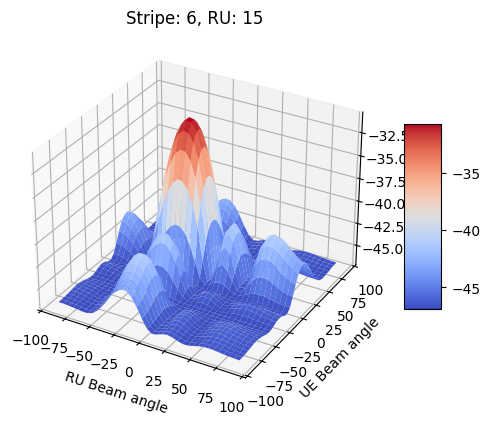

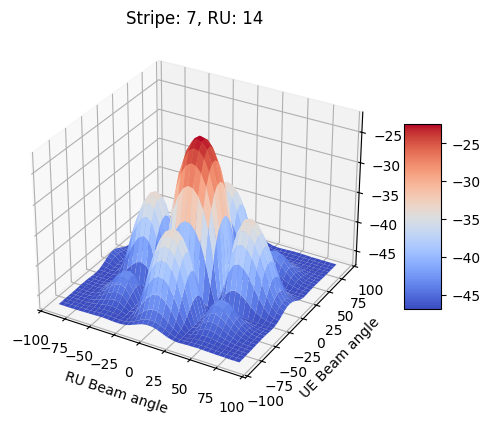

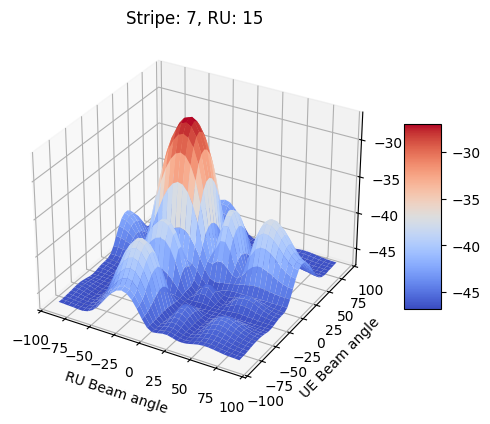

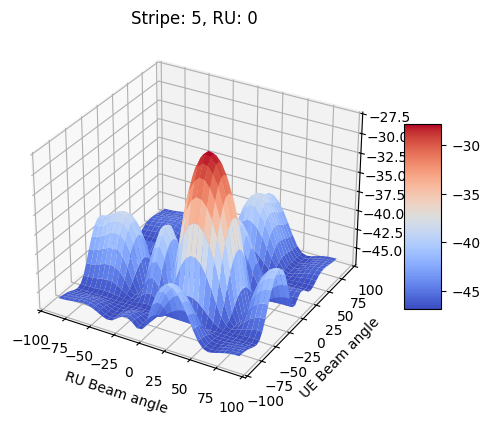

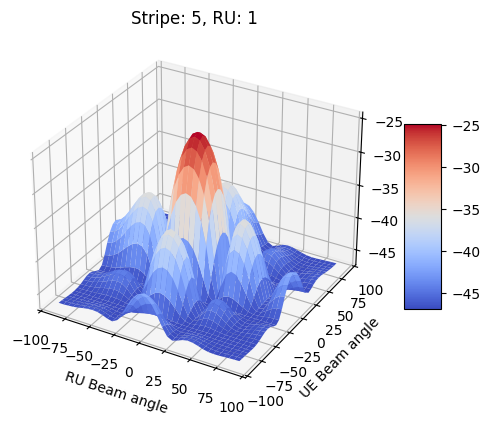

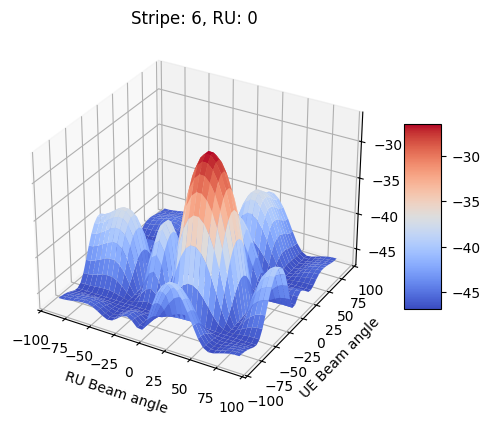

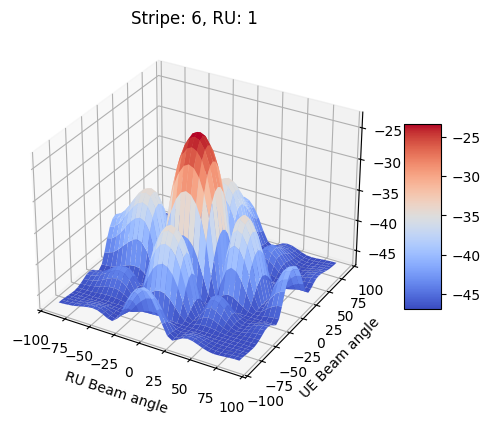

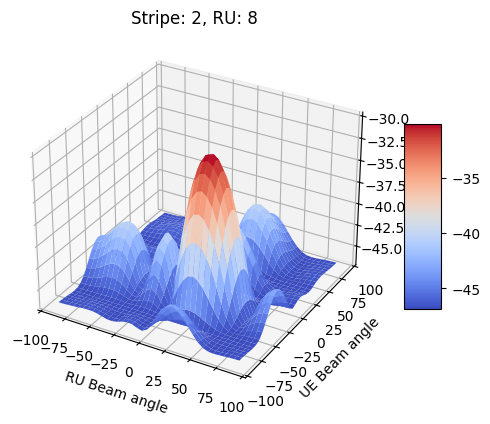

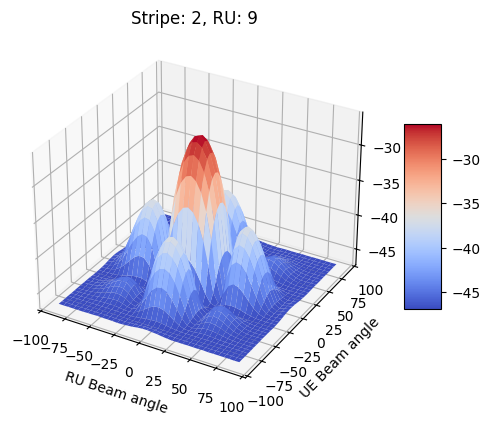

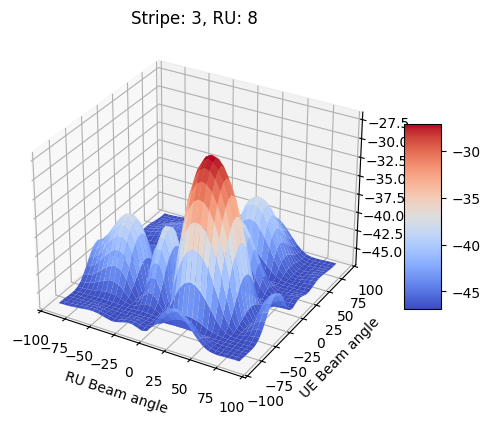

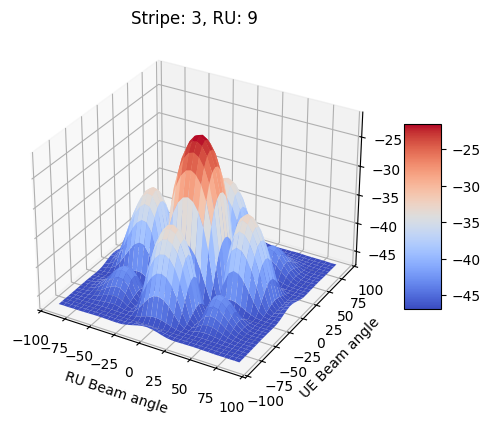

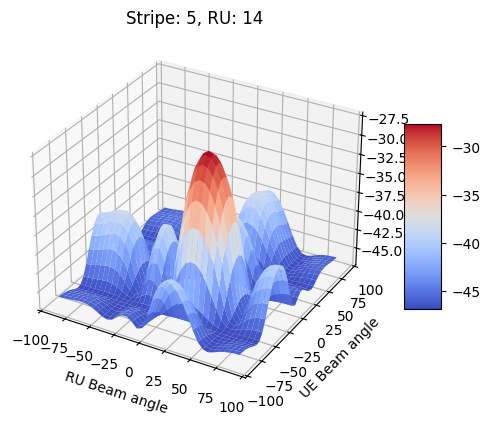

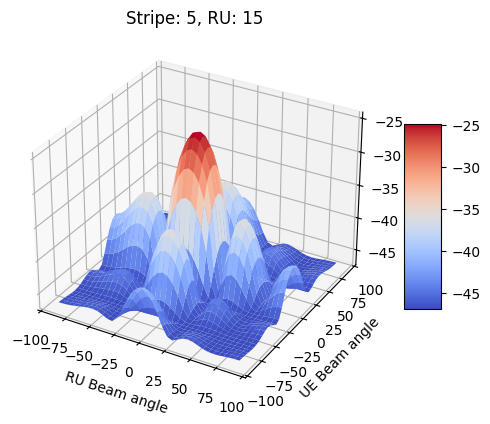

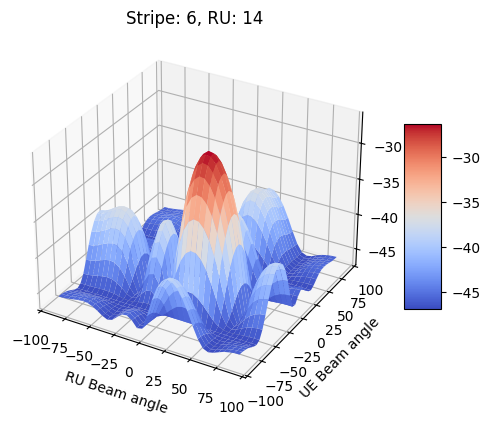

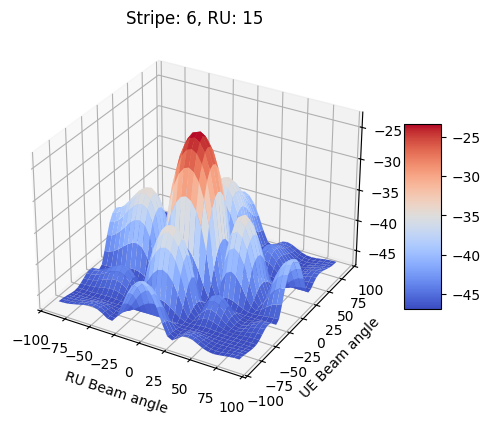

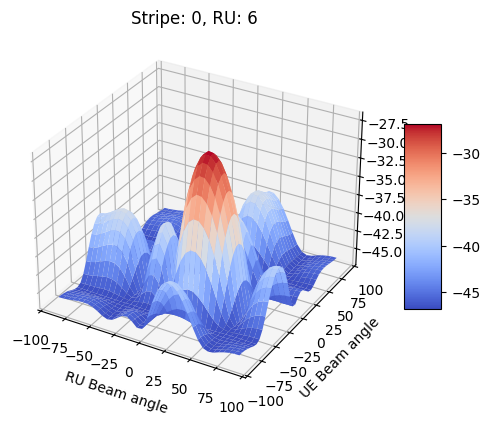

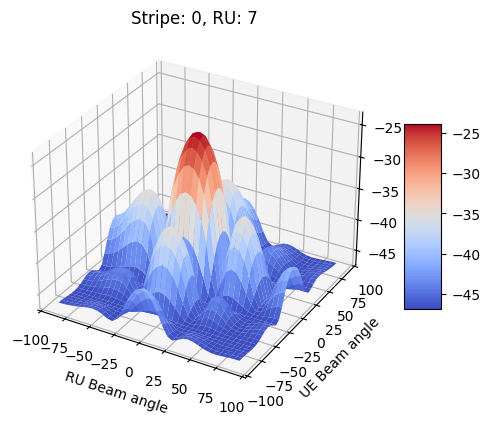

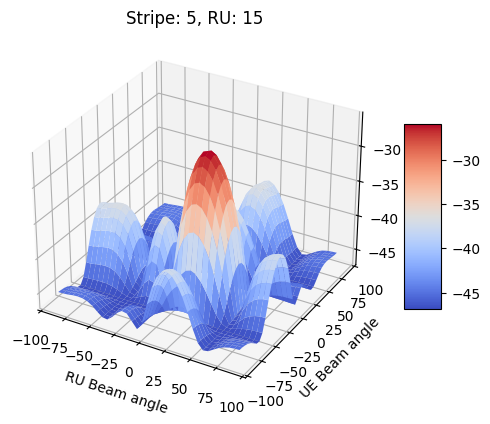

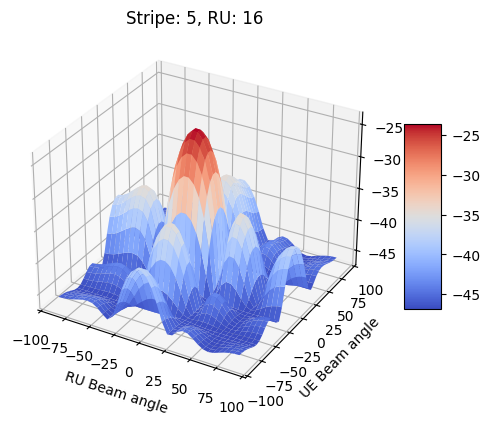

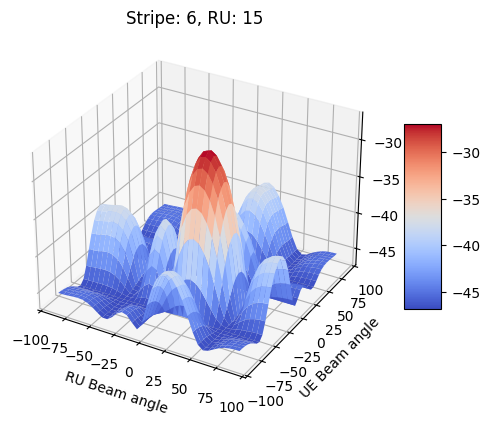

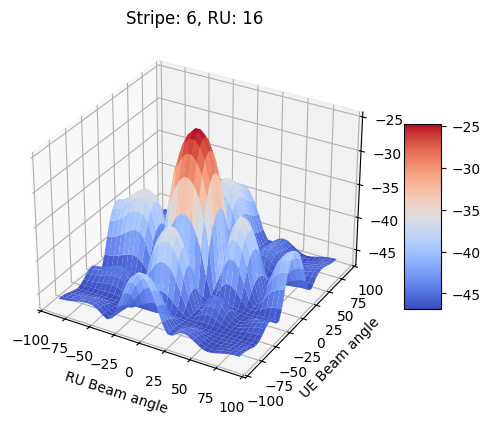

In [ ]:
ue_ds = xr.load_dataset(f"wireless_channel/sionna_dataset/{environment}/ue_locations/ue_locations.nc")

for i in range(14):
    user = ue_ds.where(ue_ds["user_id"] == i, drop=True)
    x = float(user["x"])
    y = float(user["y"])
    z = float(user["z"])

    # Read in the data for UEx
    df = pd.read_pickle(f"wireless_channel/sionna_dataset/{environment}/beam_selection/flickering_data_{i}.pkl")

    # Now for these for RUs plot all the possible beam angles on the x-axis and plot the received power on the y-axis.
    stripes = df["stripe_id"].unique()
    rus = df["ru_id"].unique()
    for stripe in stripes:
        for ru in rus:
            ru_data = df.loc[(df["stripe_id"] == stripe) & (df["ru_id"] == ru)]
            xdata = ru_data["ue_beam_id"].unique()
            ydata = ru_data["ru_beam_id"].unique()
            zdata = ru_data.pivot(index="ru_beam_id", columns="ue_beam_id", values="pavg_ru").values
            x, y = np.meshgrid(xdata, ydata)

            fig, ax = plt.subplots(subplot_kw={"projection": "3d"})
            surf = ax.plot_surface(x, y, zdata, cmap=cm.coolwarm)
            fig.colorbar(surf, shrink=0.5, aspect=5)

            ax.set_title(f"UE: {i}")
            ax.set_ylabel("UE Beam angle")
            ax.set_xlabel("RU Beam angle")
            #ax.set_zlabel("Average received Power [dB]")
            ax.set_title(f"Stripe: {stripe}, RU: {ru}")